PRIMERAS FILAS DEL DATASET:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

DIMENSIONES DESPUÉS DE LIMPIAR:
(392, 9)


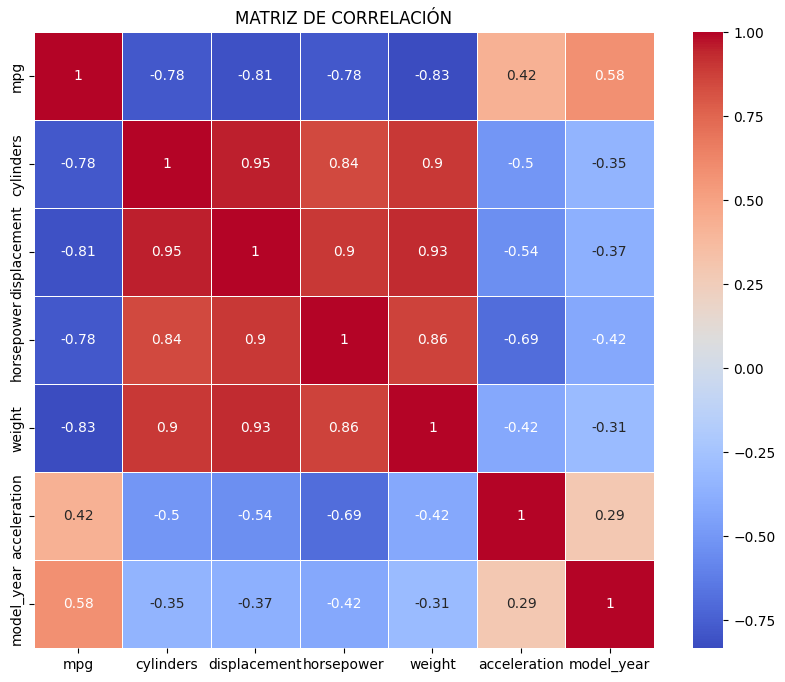


RESULTADOS DEL MODELO:
MSE: 10.602279011688333
R2: 0.7922774714022588


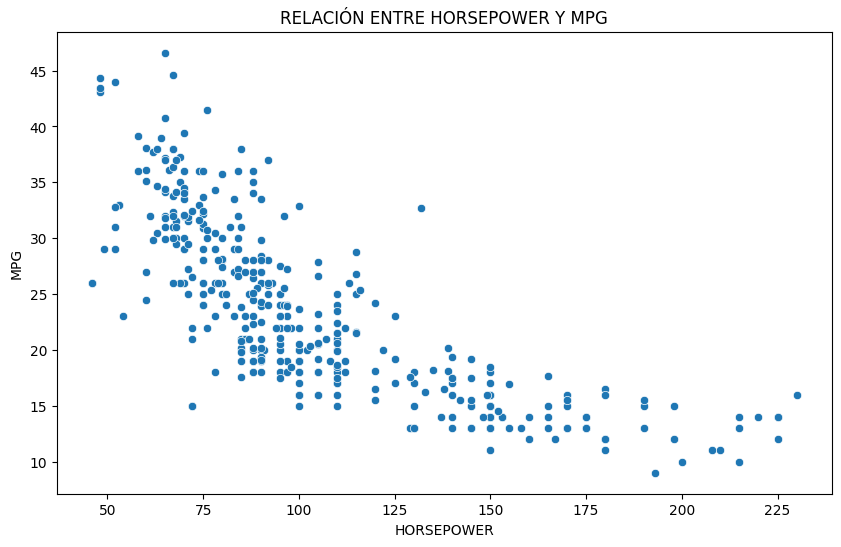

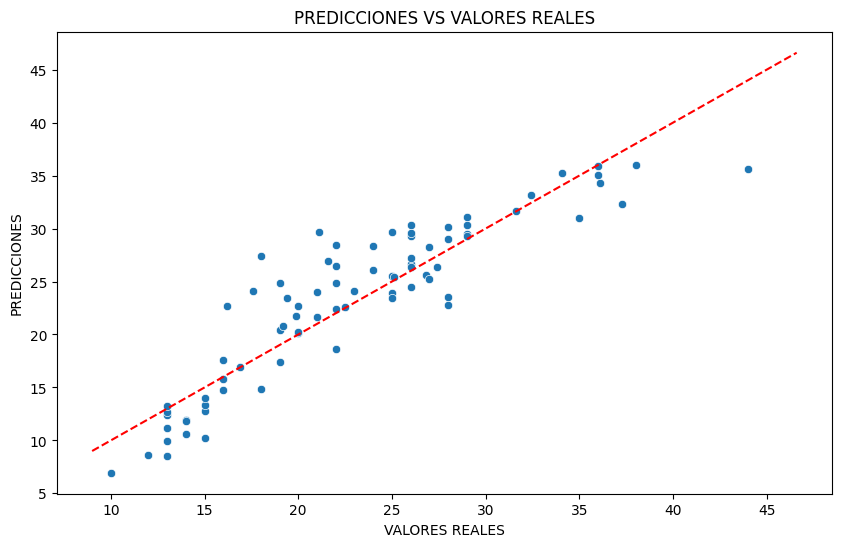

0

In [9]:
# PROYECTO: REGRESIÓN LINEAL
# DATASET VEHICLES (MPG EN SEABORN)
# ================================

# IMPORTAR LIBRERÍAS NECESARIAS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ============================================
# CARGAR EL DATASET DE VEHÍCULOS (MPG)
# ============================================

# CARGAMOS EL DATASET QUE CONTIENE INFORMACIÓN DE CARROS
# COMO RENDIMIENTO (MPG), POTENCIA, PESO, ORIGEN, ETC.
data = sns.load_dataset('mpg')

# MOSTRAMOS LAS PRIMERAS FILAS PARA ENTENDER LA ESTRUCTURA
print("PRIMERAS FILAS DEL DATASET:")
print(data.head())

# ============================================
# LIMPIEZA DE DATOS
# ============================================

# ELIMINAMOS FILAS CON VALORES NULOS PARA EVITAR ERRORES EN EL MODELO
data = data.dropna()

print("\nDIMENSIONES DESPUÉS DE LIMPIAR:")
print(data.shape)

# ============================================
# MATRIZ DE CORRELACIÓN
# ============================================

# CALCULAMOS LA CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
corr_matriz = data.corr(numeric_only=True)

# GRAFICAMOS LA MATRIZ DE CORRELACIÓN
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matriz, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('MATRIZ DE CORRELACIÓN')
plt.show()

# ============================================
# DEFINIR VARIABLES PARA EL MODELO
# ============================================

# DEFINIMOS LA VARIABLE DEPENDIENTE (LO QUE QUEREMOS PREDECIR)
y = data['mpg']

# ELIMINAMOS:
# - 'mpg' PORQUE ES LA VARIABLE OBJETIVO
# - 'name' PORQUE ES TEXTO Y EL MODELO SOLO ACEPTA NÚMEROS
X = data.drop(columns=['mpg', 'name'])

# ============================================
# DIVIDIR EN ENTRENAMIENTO Y PRUEBA
# ============================================

# 80% PARA ENTRENAR EL MODELO
# 20% PARA EVALUARLO
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# CONVERTIR VARIABLE CATEGÓRICA
# ============================================

# LA VARIABLE 'origin' ES CATEGÓRICA (USA, EUROPE, JAPAN)
# LA CONVERTIMOS A VARIABLES NUMÉRICAS
X_train_encoded = pd.get_dummies(X_train, columns=['origin'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['origin'], drop_first=True)

# ============================================
# CREAR Y ENTRENAR EL MODELO
# ============================================

# CREAMOS EL MODELO DE REGRESIÓN LINEAL
model = LinearRegression()

# ENTRENAMOS EL MODELO CON LOS DATOS DE ENTRENAMIENTO
model.fit(X_train_encoded, y_train)

# ============================================
# HACER PREDICCIONES
# ============================================

# EL MODELO INTENTA PREDECIR EL MPG CON LOS DATOS DE PRUEBA
y_pred = model.predict(X_test_encoded)

# ============================================
# EVALUAR EL MODELO
# ============================================

# CALCULAMOS EL ERROR CUADRÁTICO MEDIO
mse = mean_squared_error(y_test, y_pred)

# CALCULAMOS EL COEFICIENTE DE DETERMINACIÓN R²
r2 = r2_score(y_test, y_pred)

print("\nRESULTADOS DEL MODELO:")
print("MSE:", mse)
print("R2:", r2)

# ============================================
# GRÁFICO 1: RELACIÓN ENTRE POTENCIA Y MPG
# ============================================

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['horsepower'], y=data['mpg'])
plt.title('RELACIÓN ENTRE HORSEPOWER Y MPG')
plt.xlabel('HORSEPOWER')
plt.ylabel('MPG')
plt.show()

# ============================================
# GRÁFICO 2: PREDICCIONES VS VALORES REALES
# ============================================

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('PREDICCIONES VS VALORES REALES')
plt.xlabel('VALORES REALES')
plt.ylabel('PREDICCIONES')
plt.show()

0